In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('sales_data_with_discounts (1).csv')

In [4]:
# data loading

In [3]:
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [31]:
df.shape

(450, 13)

In [30]:
df.size

5850

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.isnull().sum()

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [5]:
# Identifying the numerical column

In [6]:
num_col = df.select_dtypes(include = ['int','float']).columns
num_col

Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
       'Discount Amount', 'Net Sales Value'],
      dtype='object')

In [22]:
for col in num_col:
    print(col, ":", float(df[col].mean()))

Volume : 5.066666666666666
Avg Price : 10453.433333333332
Total Sales Value : 33812.83555555555
Discount Rate (%) : 15.155241895330914
Discount Amount : 3346.499424342415
Net Sales Value : 30466.336131270138


In [13]:
df.describe()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


### Histograms

----------------------------------------------------------------------------------------------------


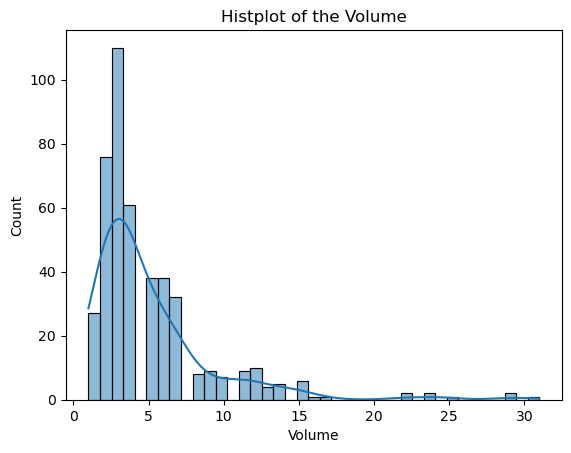

----------------------------------------------------------------------------------------------------


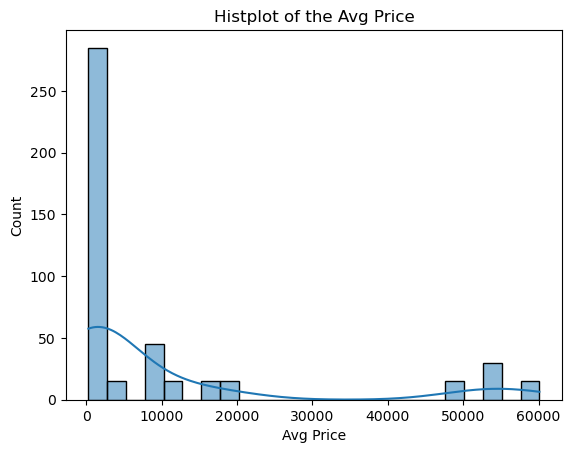

----------------------------------------------------------------------------------------------------


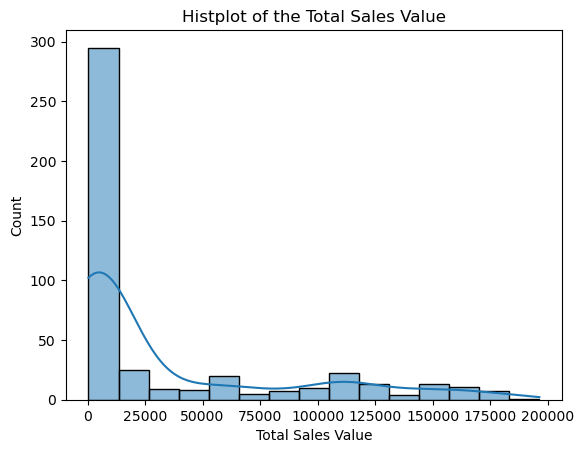

----------------------------------------------------------------------------------------------------


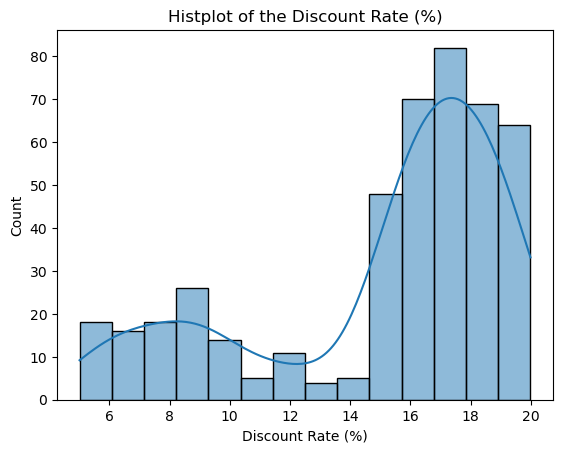

----------------------------------------------------------------------------------------------------


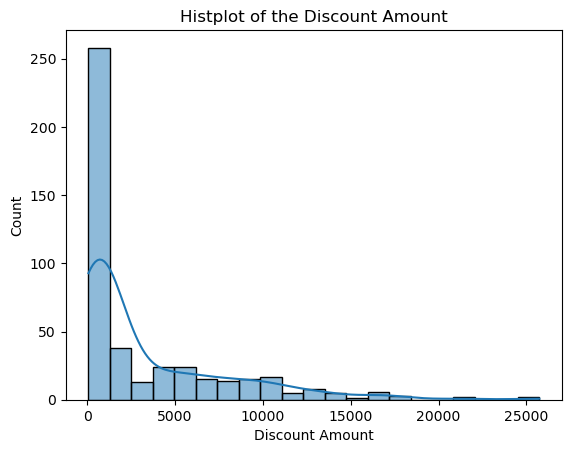

----------------------------------------------------------------------------------------------------


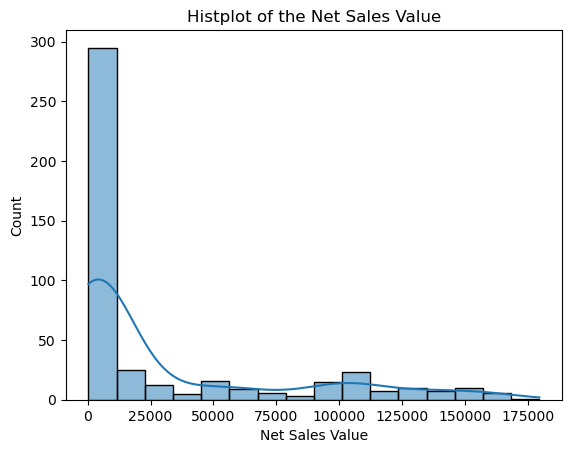

In [17]:
for col in num_col:
    plt.figure()
    sns.histplot(data = df[col],kde=True)
    plt.title(f'Histplot of the {col}')
    print('-'*100)
    plt.show()

In [18]:
# 1. Volume is asymetric (positive(+) skewed) graph
# 2. Avg Price is asymetric (positive(+) skewed) graph
# 3. Total Sales Value is asymetric (positive(+) skewed) graph
# 4. Discount Rate(%) Value is asymetric (negative(-) skewed) graph
# 5. Discount Amount Sales Value is asymetric (positive(+) skewed) graph
# 5. Net sales value  is asymetric (positive(+) skewed) graph

### Box plot 

----------------------------------------------------------------------------------------------------


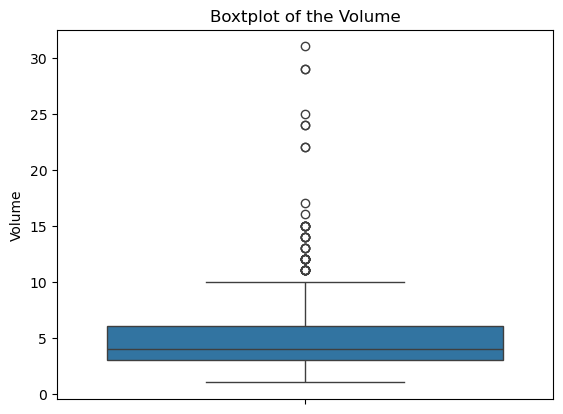

----------------------------------------------------------------------------------------------------


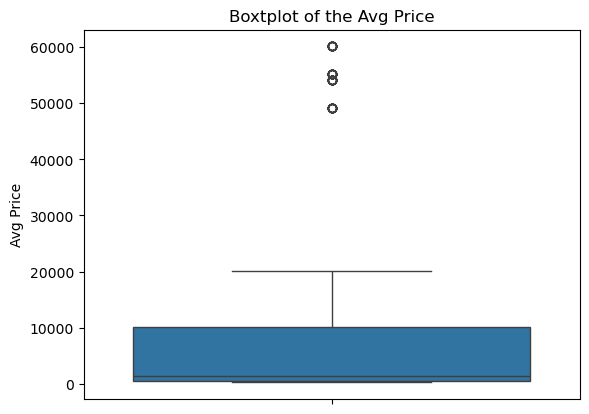

----------------------------------------------------------------------------------------------------


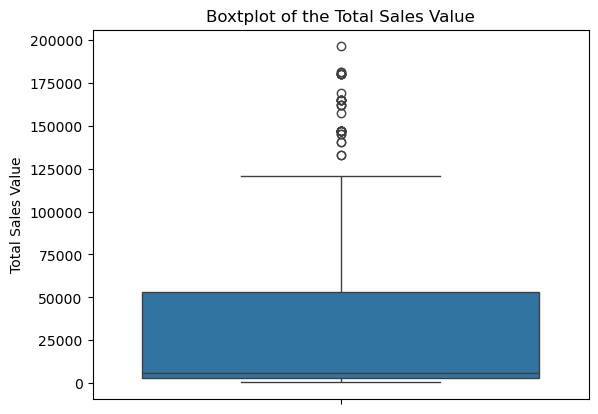

----------------------------------------------------------------------------------------------------


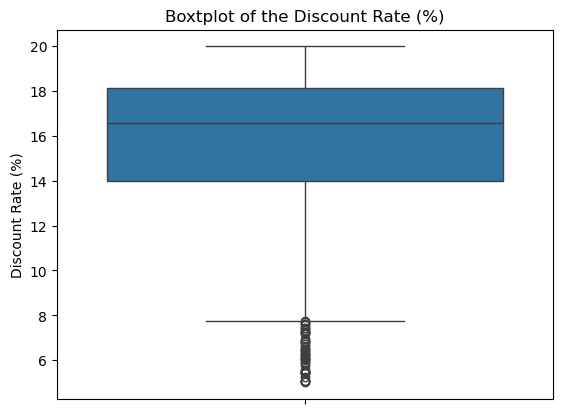

----------------------------------------------------------------------------------------------------


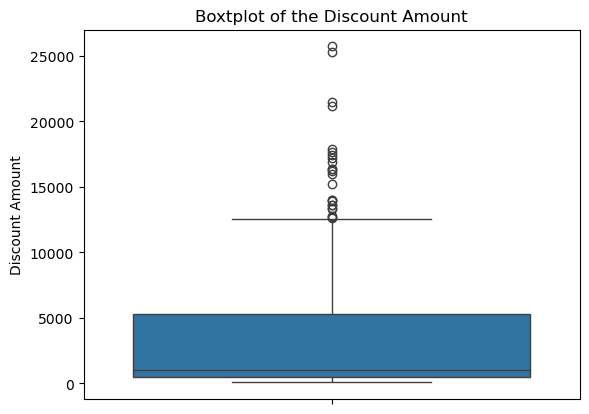

----------------------------------------------------------------------------------------------------


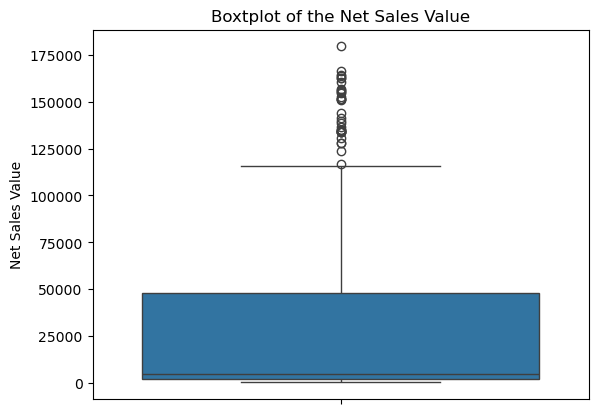

In [20]:
for col in num_col:
    plt.figure()
    sns.boxplot(data = df[col])
    plt.title(f'Boxtplot of the {col}')
    print('-'*100)
    plt.show()

In [26]:
df.describe()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


In [27]:
# 25 % represent the Q1 
# 75 % represent the Q1 
# IQR for every columns
iqr_dict = {}

for col in num_col:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    iqr_dict[col] = iqr

print(iqr_dict)

{'Volume': np.float64(3.0), 'Avg Price': np.float64(9635.0), 'Total Sales Value': np.float64(50500.0), 'Discount Rate (%)': np.float64(4.149655934050962), 'Discount Amount': np.float64(4856.03612280112), 'Net Sales Value': np.float64(45645.70420627015)}


### Boxplot

In [29]:
cat_col = df.select_dtypes(include = ['object']).columns
cat_col

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

----------------------------------------------------------------------------------------------------


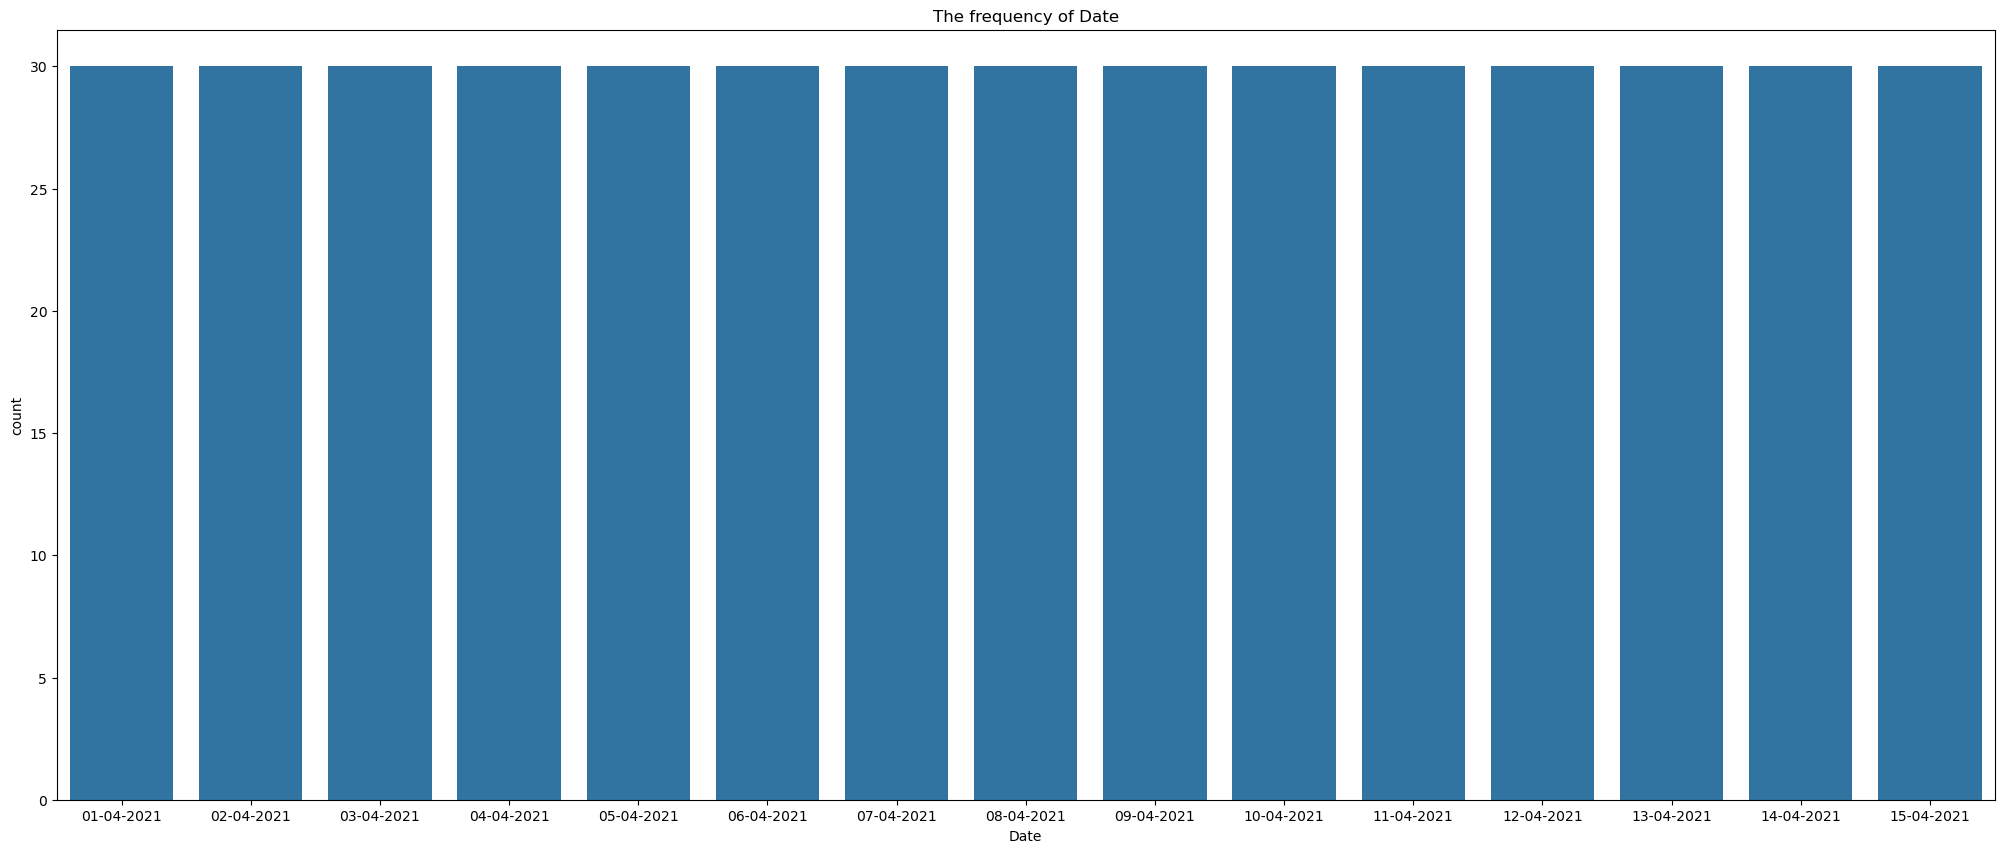

----------------------------------------------------------------------------------------------------


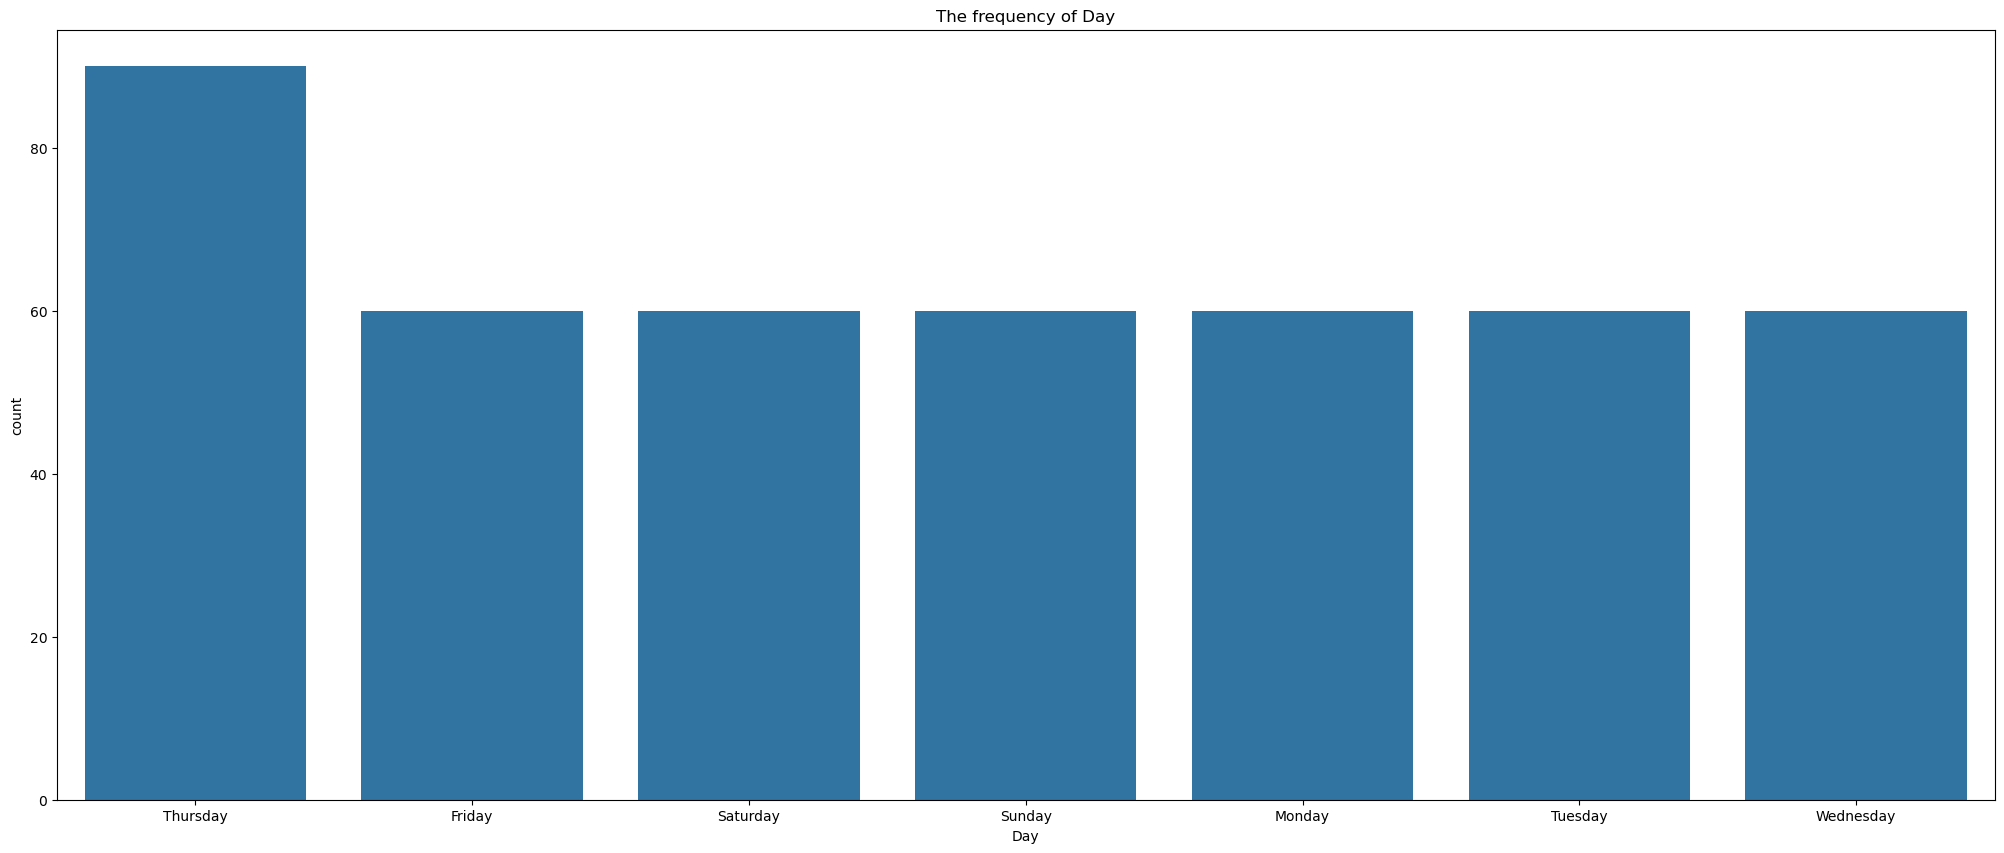

----------------------------------------------------------------------------------------------------


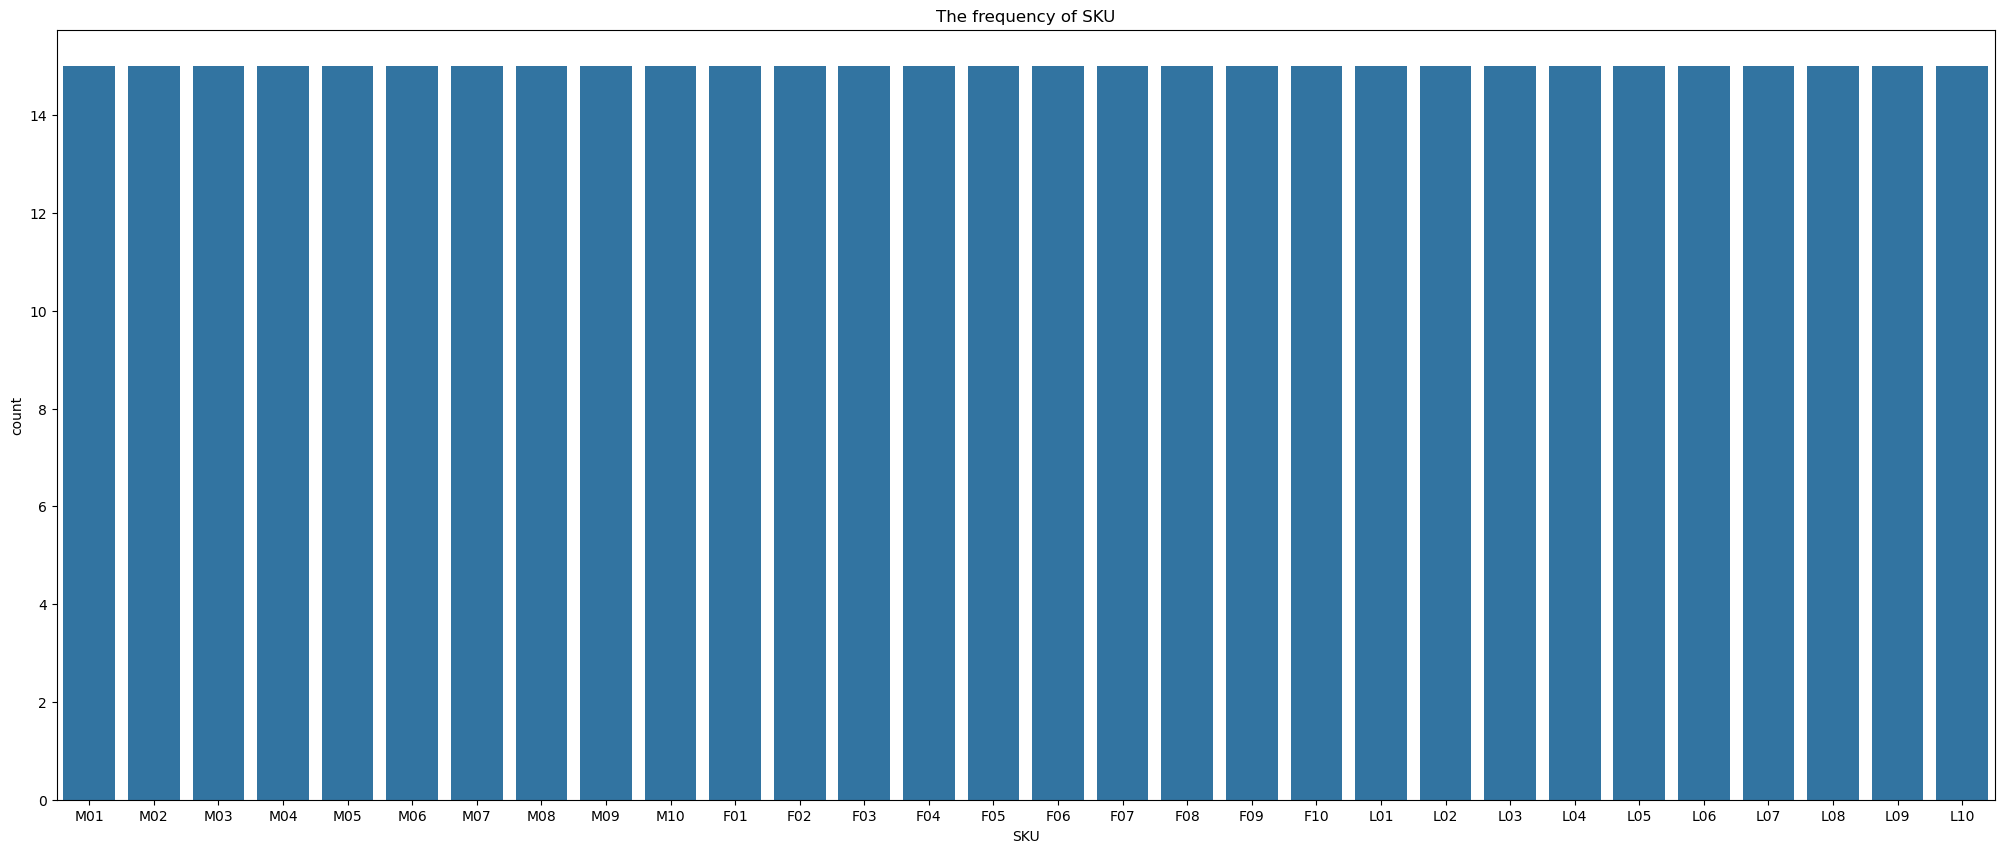

----------------------------------------------------------------------------------------------------


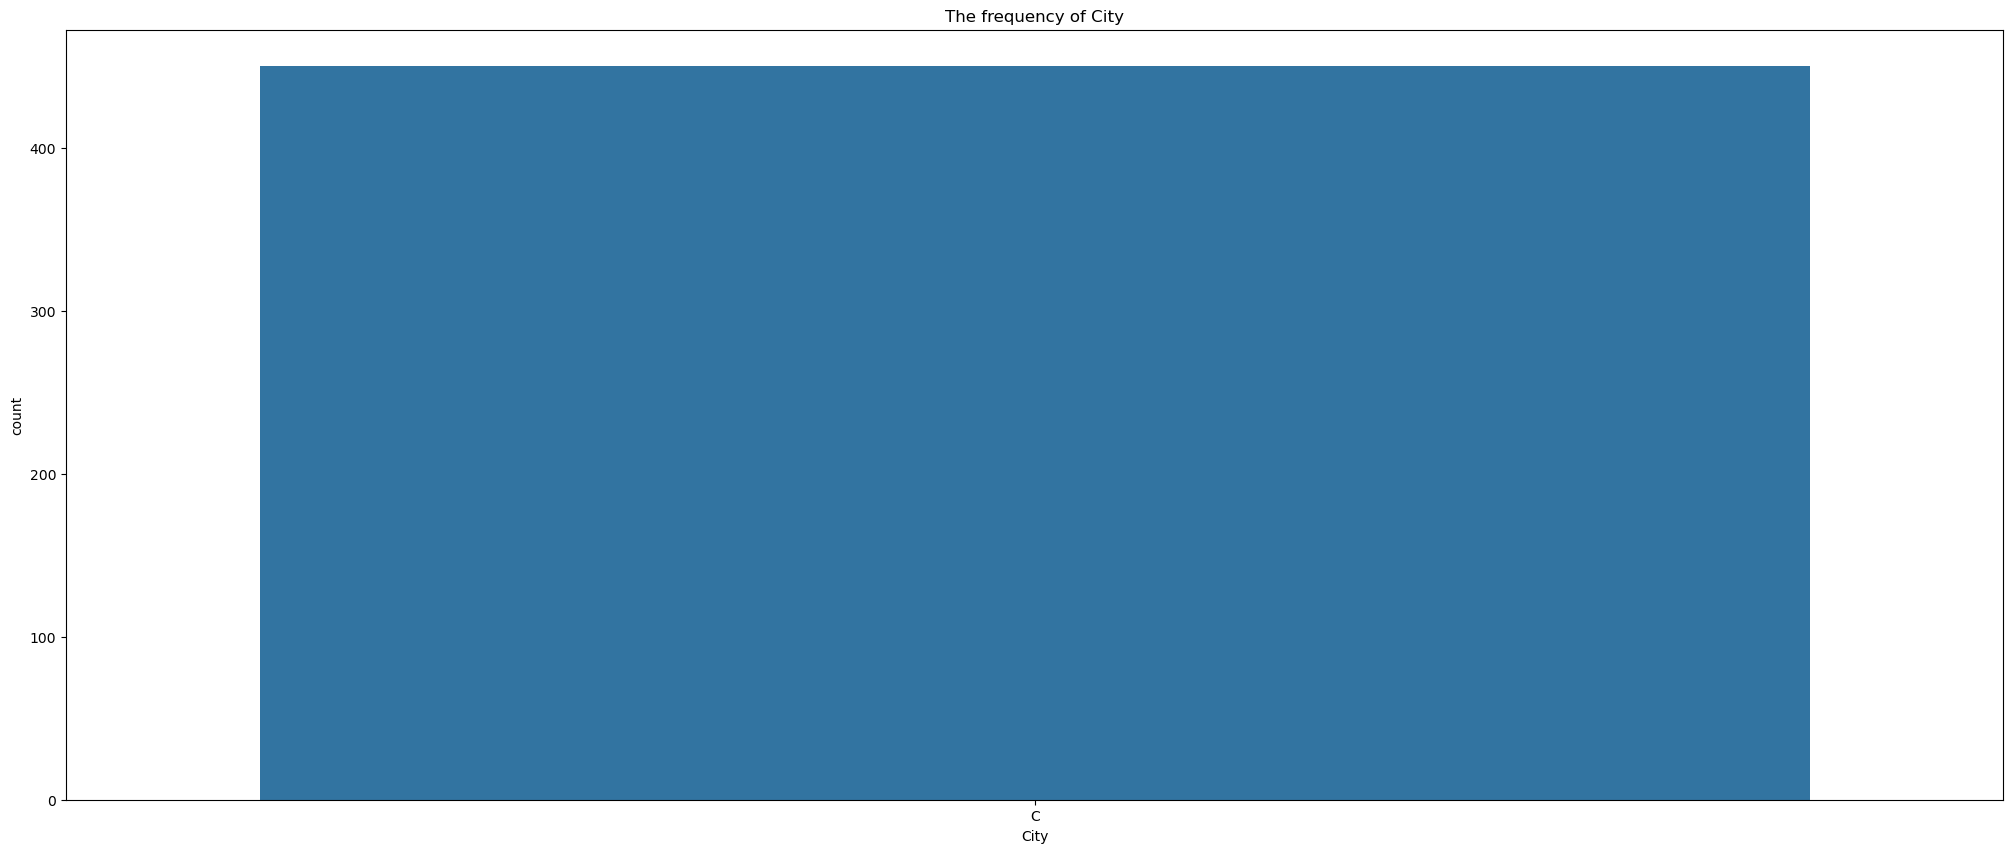

----------------------------------------------------------------------------------------------------


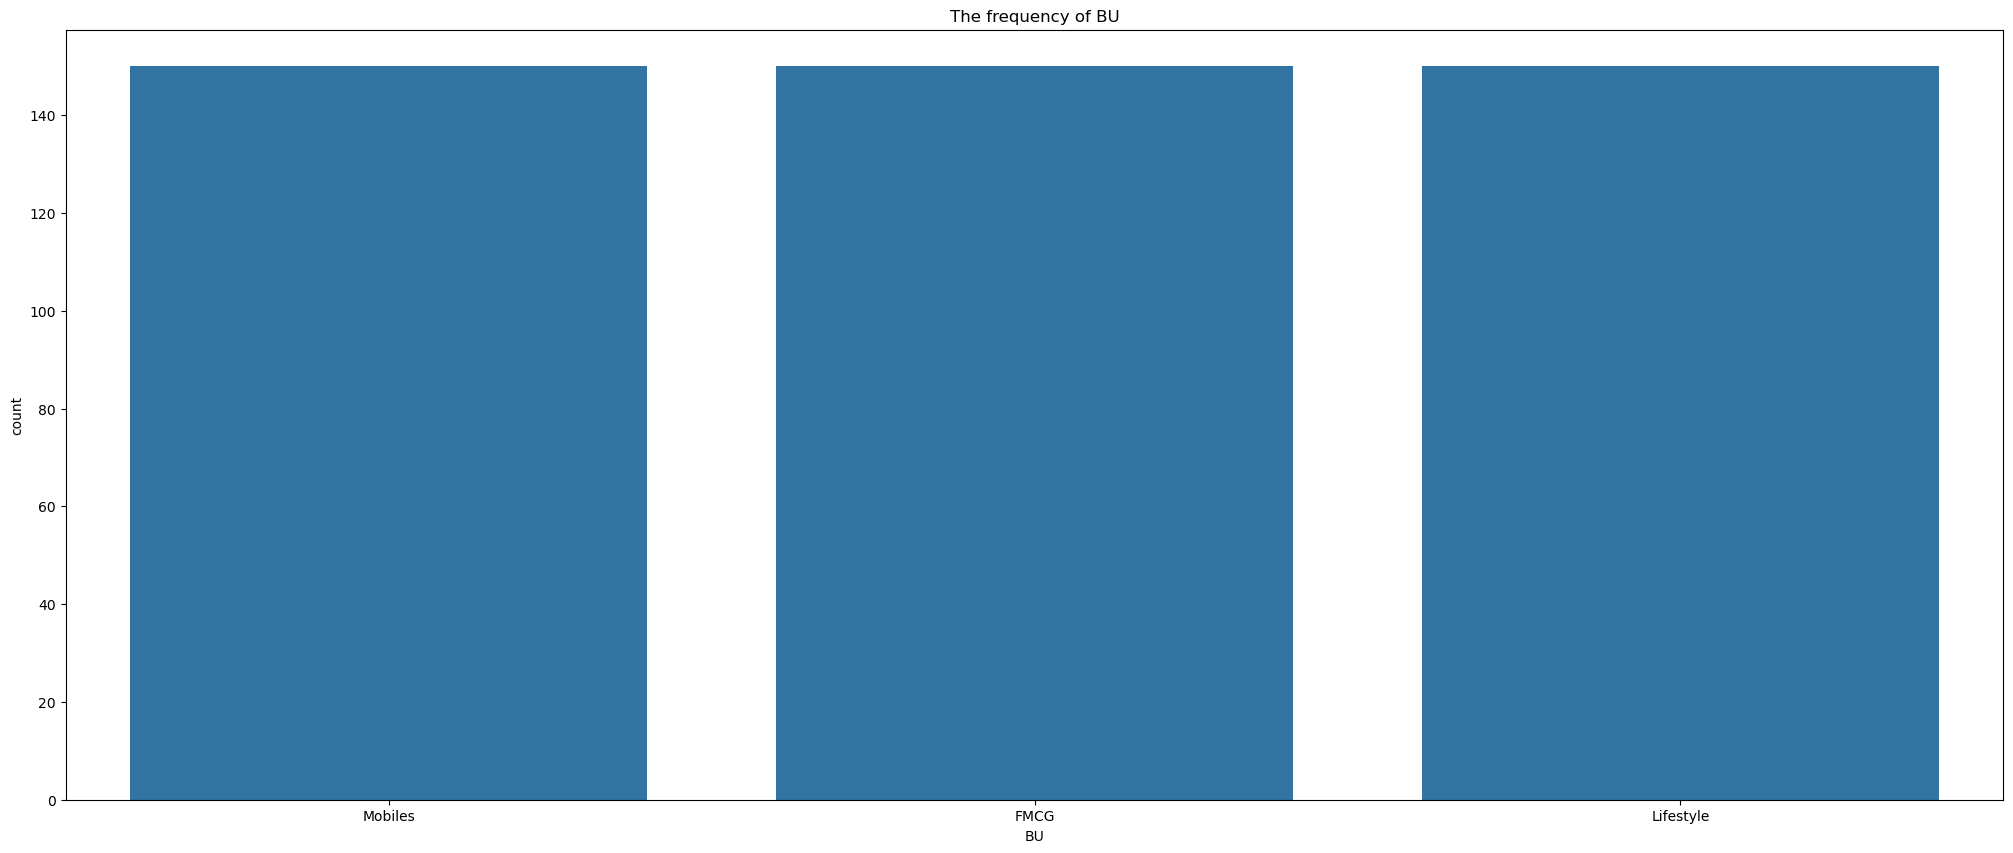

----------------------------------------------------------------------------------------------------


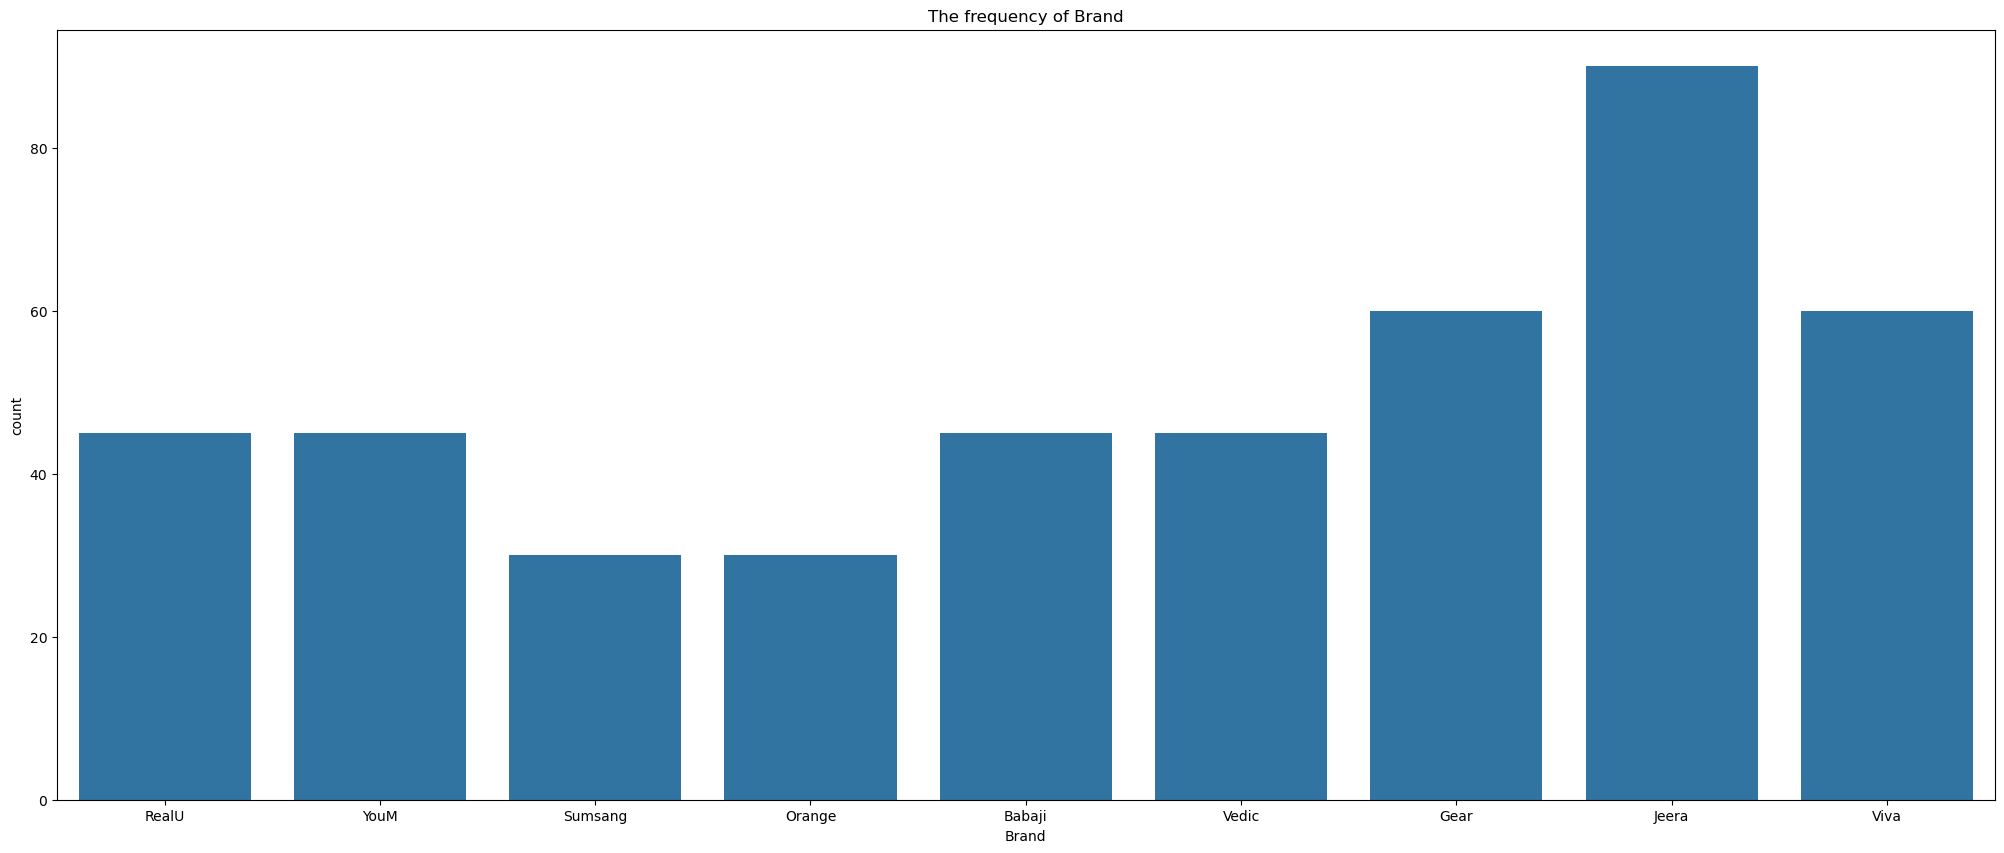

----------------------------------------------------------------------------------------------------


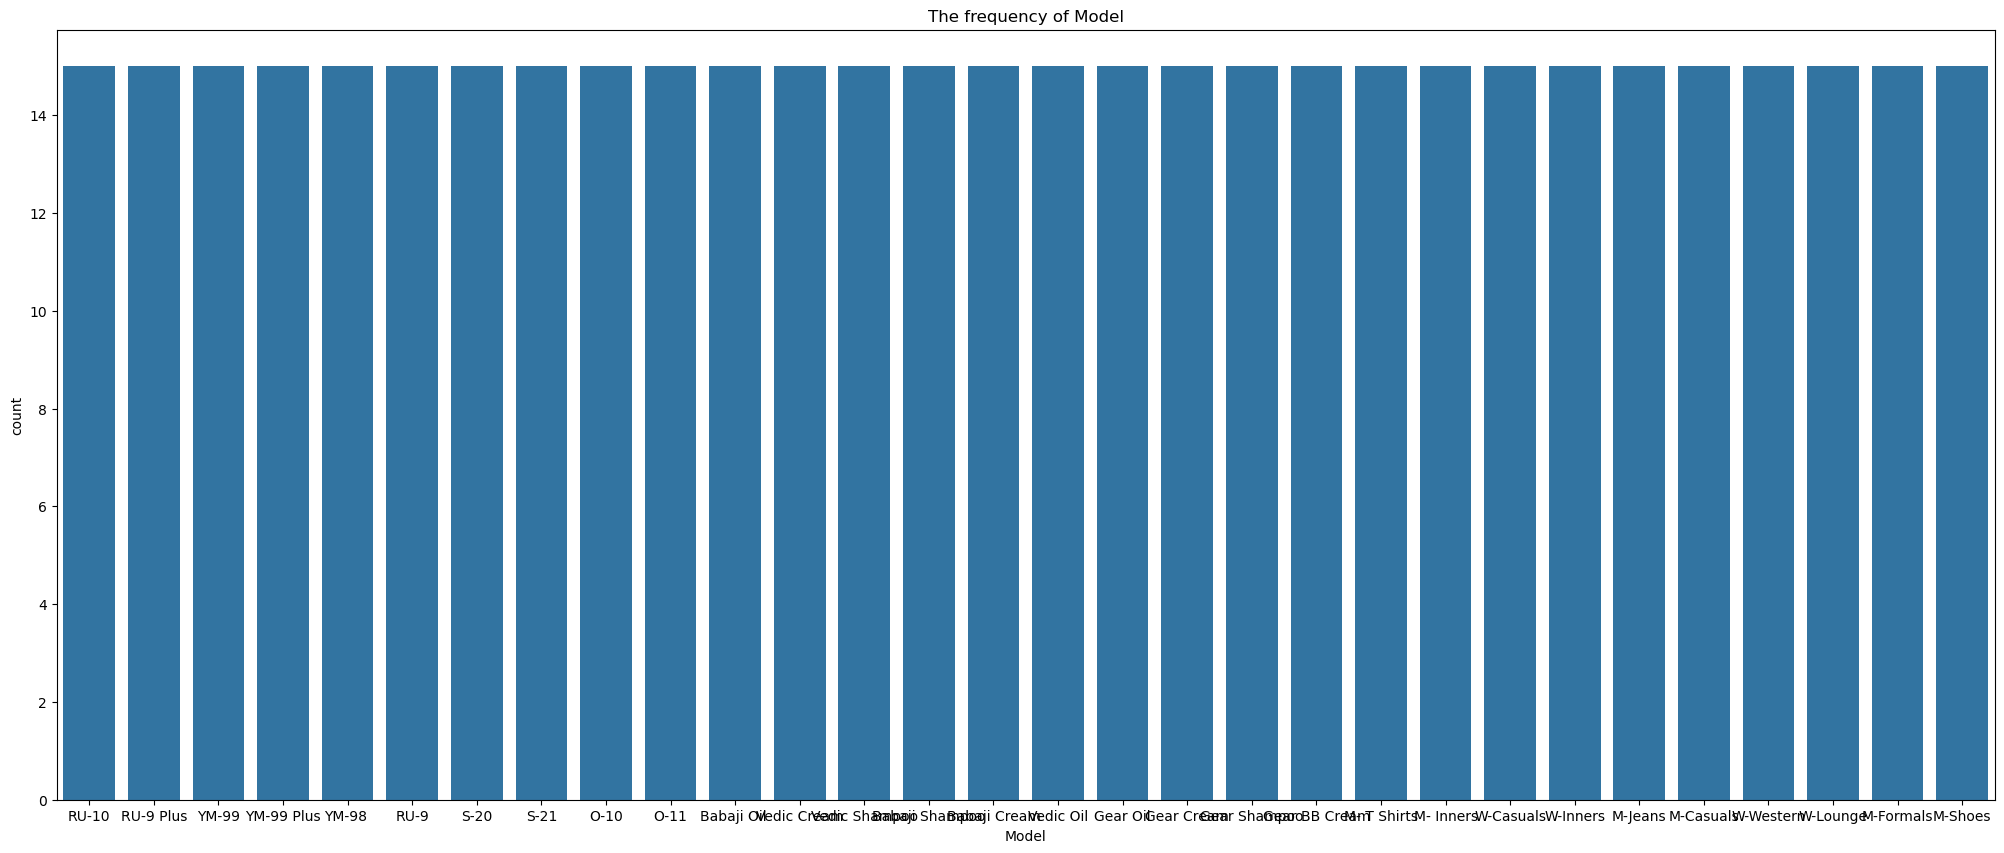

In [44]:
for col in cat_col:
    plt.figure(figsize=(25,10))
    sns.countplot(x = df[col])
    plt.title(f'The frequency of {col}')
    print('--'*50)
    plt.show()

In [45]:
for col in cat_col:
    print(f"\nColumn Name: {col}")
    
    # Frequency count
    print(df[col].value_counts())
    
    # Percentage distribution
    print((df[col].value_counts(normalize=True) * 100).round(2))


Column Name: Date
Date
01-04-2021    30
02-04-2021    30
03-04-2021    30
04-04-2021    30
05-04-2021    30
06-04-2021    30
07-04-2021    30
08-04-2021    30
09-04-2021    30
10-04-2021    30
11-04-2021    30
12-04-2021    30
13-04-2021    30
14-04-2021    30
15-04-2021    30
Name: count, dtype: int64
Date
01-04-2021    6.67
02-04-2021    6.67
03-04-2021    6.67
04-04-2021    6.67
05-04-2021    6.67
06-04-2021    6.67
07-04-2021    6.67
08-04-2021    6.67
09-04-2021    6.67
10-04-2021    6.67
11-04-2021    6.67
12-04-2021    6.67
13-04-2021    6.67
14-04-2021    6.67
15-04-2021    6.67
Name: proportion, dtype: float64

Column Name: Day
Day
Thursday     90
Friday       60
Saturday     60
Sunday       60
Monday       60
Tuesday      60
Wednesday    60
Name: count, dtype: int64
Day
Thursday     20.00
Friday       13.33
Saturday     13.33
Sunday       13.33
Monday       13.33
Tuesday      13.33
Wednesday    13.33
Name: proportion, dtype: float64

Column Name: SKU
SKU
M01    15
M02    15
